In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Carregar dados

In [2]:
df = pd.read_csv('dados/df_final.csv')
print(f"Shape original: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
df.head(2)

Shape original: 5,819,079 linhas x 46 colunas


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DEST_AIRPORT_NAME,DEST_CITY,DEST_STATE,DEST_COUNTRY,DEST_LATITUDE,DEST_LONGITUDE,dia_semana,hora_partida
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,Quinta,0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559,Quinta,0


## 2. Filtrar voos cancelados e desviados

Voos cancelados nao possuem atraso (target indefinido). Voos desviados tem comportamento anomalo que polui o target de chegada. Ambos serao removidos.

In [3]:
n_cancelados = (df['CANCELLED'] == 1).sum()
n_desviados  = (df['DIVERTED'] == 1).sum()
print(f"Cancelados: {n_cancelados:,} ({n_cancelados/len(df)*100:.2f}%)")
print(f"Desviados:  {n_desviados:,} ({n_desviados/len(df)*100:.2f}%)")

df = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()
print(f"\nApos filtro: {df.shape[0]:,} linhas")

Cancelados: 89,884 (1.54%)
Desviados:  15,187 (0.26%)

Apos filtro: 5,714,008 linhas


## 3. Dropar colunas inuteis, redundantes e com data leakage

In [4]:
cols_drop = [
    # Variancia zero (apenas 1 valor)
    'YEAR',                   # so 2015
    'ORIGIN_COUNTRY',         # so "USA"
    'DEST_COUNTRY',           # so "USA"

    # Identificadores -- alta cardinalidade, nao generalizaveis
    'TAIL_NUMBER',
    'FLIGHT_NUMBER',

    # Redundantes (ja temos codigo do aeroporto / airline)
    'AIRLINE_NAME',
    'ORIGIN_AIRPORT_NAME',
    'DEST_AIRPORT_NAME',
    'ORIGIN_CITY',
    'DEST_CITY',

    # Data leakage -- so existem apos o evento
    'DEPARTURE_TIME',
    'ARRIVAL_TIME',
    'WHEELS_OFF',
    'WHEELS_ON',
    'ELAPSED_TIME',
    'AIR_TIME',
    'TAXI_IN',
    'TAXI_OUT',
    'DIVERTED',

    # >80% nulos + decomposicao do atraso (leakage direto)
    'CANCELLATION_REASON',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY',

    # Filtro ja aplicado -- constante = 0
    'CANCELLED',
]

# Dropar apenas colunas que existem no df
cols_drop_existing = [c for c in cols_drop if c in df.columns]
df.drop(columns=cols_drop_existing, inplace=True)

print(f"Colunas removidas: {len(cols_drop_existing)}")
print(f"Colunas restantes: {df.shape[1]}")
print(f"\nColunas atuais:\n{list(df.columns)}")

Colunas removidas: 26
Colunas restantes: 20

Colunas atuais:
['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_DELAY', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY', 'ORIGIN_STATE', 'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE', 'DEST_STATE', 'DEST_LATITUDE', 'DEST_LONGITUDE', 'dia_semana', 'hora_partida']


## 4. Criar targets de atraso

In [5]:
THRESHOLD = 10  # minutos (mesmo definido na EDA)

df['ATRASO_SAIDA']   = (df['DEPARTURE_DELAY'] >= THRESHOLD).astype(int)
df['ATRASO_CHEGADA'] = (df['ARRIVAL_DELAY']   >= THRESHOLD).astype(int)

print(f"ATRASO_SAIDA   -> {df['ATRASO_SAIDA'].mean()*100:.1f}% positivos")
print(f"ATRASO_CHEGADA -> {df['ATRASO_CHEGADA'].mean()*100:.1f}% positivos")

# Dropar os delays originais (nao serao features, so serviram para criar o target)
df.drop(columns=['DEPARTURE_DELAY', 'ARRIVAL_DELAY'], inplace=True)
print(f"\nColunas apos criar targets e dropar delays: {df.shape[1]}")

ATRASO_SAIDA   -> 22.5% positivos
ATRASO_CHEGADA -> 23.0% positivos

Colunas apos criar targets e dropar delays: 20


## 5. Tratar nulos restantes

In [6]:
# Verificar estado atual de nulos
null_pct = (df.isnull().mean() * 100).round(2)
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)
print("Colunas com nulos (apos drops):")
print(null_pct.to_string())
print(f"\nTotal de linhas: {len(df):,}")

Colunas com nulos (apos drops):
ORIGIN_LATITUDE     8.53
ORIGIN_LONGITUDE    8.53
DEST_LONGITUDE      8.53
DEST_LATITUDE       8.53
ORIGIN_STATE        8.45
DEST_STATE          8.45

Total de linhas: 5,714,008


In [7]:
# Coordenadas e info de aeroporto (~8% nulos): dropar linhas
# Essas colunas sao todas nulas juntas (mesmo bloco de airports sem match)
cols_geo = ['ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE', 'DEST_LATITUDE', 'DEST_LONGITUDE',
            'ORIGIN_STATE', 'DEST_STATE']
cols_geo_existing = [c for c in cols_geo if c in df.columns]

n_antes = len(df)
df.dropna(subset=cols_geo_existing, inplace=True)
n_depois = len(df)
print(f"Linhas removidas por nulos em geo/state: {n_antes - n_depois:,} ({(n_antes-n_depois)/n_antes*100:.2f}%)")
print(f"Linhas restantes: {n_depois:,}")

# Numericas restantes com <2% nulos: imputar com mediana
num_cols_with_nulls = df.select_dtypes(include='number').columns[df.select_dtypes(include='number').isnull().any()].tolist()
for col in num_cols_with_nulls:
    pct = df[col].isnull().mean() * 100
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"  {col}: {pct:.2f}% nulos -> imputado mediana ({median_val:.1f})")

# Categoricas restantes com nulos: imputar com moda
cat_cols_with_nulls = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()].tolist()
for col in cat_cols_with_nulls:
    pct = df[col].isnull().mean() * 100
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"  {col}: {pct:.2f}% nulos -> imputado moda ('{mode_val}')")

# Verificacao final
total_nulls = df.isnull().sum().sum()
print(f"\nTotal de nulos restantes: {total_nulls}")

Linhas removidas por nulos em geo/state: 492,008 (8.61%)
Linhas restantes: 5,222,000

Total de nulos restantes: 0


## 6. Capping de outliers no percentil 99

In [8]:
# Aplicar winsorization (capping) no p1 e p99 para numericas continuas
# Excluir colunas que nao faz sentido cappar (IDs, targets, coordenadas, temporais discretas)
cols_no_cap = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL',
               'hora_partida', 'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE',
               'DEST_LATITUDE', 'DEST_LONGITUDE',
               'ATRASO_SAIDA', 'ATRASO_CHEGADA']

num_cols = df.select_dtypes(include='number').columns.tolist()
cols_to_cap = [c for c in num_cols if c not in cols_no_cap]

print("Capping p1/p99 aplicado em:")
for col in cols_to_cap:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    n_capped = ((df[col] < p01) | (df[col] > p99)).sum()
    df[col] = df[col].clip(lower=p01, upper=p99)
    print(f"  {col}: [{p01:.1f}, {p99:.1f}] -- {n_capped:,} valores cappados")

print(f"\nShape atual: {df.shape}")

Capping p1/p99 aplicado em:
  SCHEDULED_TIME: [44.0, 377.0] -- 102,865 valores cappados
  DISTANCE: [100.0, 2588.0] -- 96,595 valores cappados

Shape atual: (5222000, 20)


## 7. Agrupar categorias raras em "OUTROS" (<1% de frequencia)

In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
# Incluir dia_semana se string
if 'dia_semana' not in cat_cols and 'dia_semana' in df.columns:
    cat_cols.append('dia_semana')

FREQ_THRESHOLD = 0.01  # 1%

for col in cat_cols:
    freq = df[col].value_counts(normalize=True)
    rare_cats = freq[freq < FREQ_THRESHOLD].index.tolist()
    if rare_cats:
        n_before = df[col].nunique()
        df[col] = df[col].where(~df[col].isin(rare_cats), other='OUTROS')
        n_after = df[col].nunique()
        n_rows_affected = df[col].eq('OUTROS').sum()
        print(f"{col}: {n_before} -> {n_after} categorias "
              f"({len(rare_cats)} agrupadas em OUTROS, {n_rows_affected:,} registros)")
    else:
        print(f"{col}: {df[col].nunique()} categorias -- nenhuma rara")

AIRLINE: 14 categorias -- nenhuma rara
ORIGIN_AIRPORT: 319 -> 29 categorias (291 agrupadas em OUTROS, 1,765,822 registros)
DESTINATION_AIRPORT: 319 -> 29 categorias (291 agrupadas em OUTROS, 1,769,043 registros)
ORIGIN_STATE: 54 -> 26 categorias (29 agrupadas em OUTROS, 486,499 registros)
DEST_STATE: 54 -> 26 categorias (29 agrupadas em OUTROS, 487,758 registros)
dia_semana: 7 categorias -- nenhuma rara


## 8. Criar novas features

In [10]:
# --- PERIODO_DIA ---
def periodo_dia(h):
    if h < 6:
        return 'Madrugada'
    elif h < 12:
        return 'Manha'
    elif h < 18:
        return 'Tarde'
    else:
        return 'Noite'

df['PERIODO_DIA'] = df['hora_partida'].apply(periodo_dia)

# --- HORA_PICO ---
# Horarios de pico aeroportuario: 6-9h e 17-20h
df['HORA_PICO'] = df['hora_partida'].apply(lambda h: 1 if (6 <= h <= 9) or (17 <= h <= 20) else 0)

# --- TIPO_DIA_SEMANA ---
# DAY_OF_WEEK: 1=Mon .. 7=Sun
def tipo_dia_semana(dow):
    if dow <= 2:
        return 'Comeco'   # Seg/Ter
    elif dow <= 4:
        return 'Meio'     # Qua/Qui
    else:
        return 'Fim'      # Sex/Sab/Dom

df['TIPO_DIA_SEMANA'] = df['DAY_OF_WEEK'].apply(tipo_dia_semana)

# --- FIM_DE_SEMANA ---
df['FIM_DE_SEMANA'] = (df['DAY_OF_WEEK'] >= 6).astype(int)

# --- ESTACAO (hemisferio norte) ---
def estacao(m):
    if m in [12, 1, 2]:
        return 'Inverno'
    elif m in [3, 4, 5]:
        return 'Primavera'
    elif m in [6, 7, 8]:
        return 'Verao'
    else:
        return 'Outono'

df['ESTACAO'] = df['MONTH'].apply(estacao)

# --- FAIXA_DISTANCIA ---
def faixa_distancia(d):
    if d < 500:
        return 'Curta'
    elif d < 1500:
        return 'Media'
    else:
        return 'Longa'

df['FAIXA_DISTANCIA'] = df['DISTANCE'].apply(faixa_distancia)

# --- DIA_MES_GRUPO ---
def dia_mes_grupo(d):
    if d <= 10:
        return 'Comeco'
    elif d <= 20:
        return 'Meio'
    else:
        return 'Fim'

df['DIA_MES_GRUPO'] = df['DAY'].apply(dia_mes_grupo)

# --- ROTA ---
df['ROTA'] = df['ORIGIN_AIRPORT'] + '-' + df['DESTINATION_AIRPORT']

# Resumo das novas features
new_features = ['PERIODO_DIA', 'HORA_PICO', 'TIPO_DIA_SEMANA', 'FIM_DE_SEMANA',
                'ESTACAO', 'FAIXA_DISTANCIA', 'DIA_MES_GRUPO', 'ROTA']
print("Novas features criadas:")
for f in new_features:
    if pd.api.types.is_string_dtype(df[f]) or df[f].dtype == 'object':
        print(f"  {f}: {df[f].nunique()} categorias -> {df[f].value_counts().to_dict()}")
    else:
        print(f"  {f}: mean={df[f].mean():.3f}")

Novas features criadas:
  PERIODO_DIA: 4 categorias -> {'Manha': 2031201, 'Tarde': 1920527, 'Noite': 1143270, 'Madrugada': 127002}
  HORA_PICO: mean=0.489
  TIPO_DIA_SEMANA: 3 categorias -> {'Fim': 2133551, 'Meio': 1551513, 'Comeco': 1536936}
  FIM_DE_SEMANA: mean=0.261
  ESTACAO: 4 categorias -> {'Verao': 1508190, 'Primavera': 1458244, 'Inverno': 1332602, 'Outono': 922964}
  FAIXA_DISTANCIA: 3 categorias -> {'Media': 2618398, 'Curta': 1890518, 'Longa': 713084}
  DIA_MES_GRUPO: 3 categorias -> {'Fim': 1771254, 'Meio': 1735423, 'Comeco': 1715323}
  ROTA: 749 categorias -> {'OUTROS-OUTROS': 285506, 'ATL-OUTROS': 206966, 'OUTROS-ATL': 206568, 'ORD-OUTROS': 158594, 'OUTROS-ORD': 157608, 'DFW-OUTROS': 139009, 'OUTROS-DFW': 138391, 'DEN-OUTROS': 97718, 'OUTROS-DEN': 97472, 'IAH-OUTROS': 78475, 'OUTROS-IAH': 78239, 'LAX-OUTROS': 70896, 'OUTROS-LAX': 70614, 'PHX-OUTROS': 61803, 'OUTROS-PHX': 61718, 'OUTROS-MSP': 50260, 'MSP-OUTROS': 50152, 'OUTROS-LAS': 49459, 'LAS-OUTROS': 49424, 'OUTROS-SFO'

In [11]:
# Agrupar ROTA rara em OUTROS (muitas combinacoes possiveis)
rota_freq = df['ROTA'].value_counts(normalize=True)
rare_rotas = rota_freq[rota_freq < FREQ_THRESHOLD].index
n_before = df['ROTA'].nunique()
df['ROTA'] = df['ROTA'].where(~df['ROTA'].isin(rare_rotas), other='OUTROS')
n_after = df['ROTA'].nunique()
print(f"ROTA: {n_before} -> {n_after} categorias ({len(rare_rotas)} raras agrupadas)")

ROTA: 749 -> 16 categorias (734 raras agrupadas)


## 9. Volume de voos por aeroporto/hora (proxy de congestionamento)

Contar quantos voos partem do mesmo aeroporto de origem na mesma hora do mesmo dia. Funciona como proxy de congestionamento -- quanto mais voos saindo na mesma janela, maior a chance de atrasos em cascata.

VOL_VOOS_ORIGEM:
count    5222000.0
mean         137.7
std          166.2
min            1.0
25%           21.0
50%           42.0
75%          290.0
max          710.0
Name: VOL_VOOS_ORIGEM, dtype: float64

VOL_VOOS_DESTINO:
count    5222000.0
mean         127.6
std          143.4
min            1.0
25%           20.0
50%           41.0
75%          300.0
max          425.0
Name: VOL_VOOS_DESTINO, dtype: float64


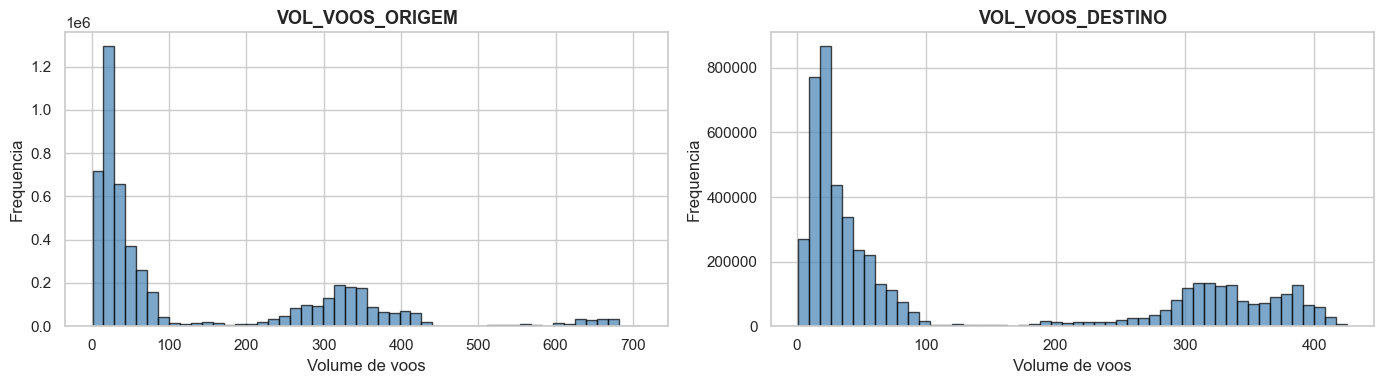

In [12]:
# Volume de voos saindo do mesmo aeroporto na mesma data/hora
vol_saida = (df.groupby(['ORIGIN_AIRPORT', 'MONTH', 'DAY', 'hora_partida'])
               .size()
               .reset_index(name='VOL_VOOS_ORIGEM'))

df = df.merge(vol_saida, on=['ORIGIN_AIRPORT', 'MONTH', 'DAY', 'hora_partida'], how='left')

# Volume de voos chegando no mesmo aeroporto na mesma data/hora
# Usar SCHEDULED_ARRIVAL convertido para hora
df['hora_chegada'] = (df['SCHEDULED_ARRIVAL'] // 100).astype(int).clip(0, 23)

vol_chegada = (df.groupby(['DESTINATION_AIRPORT', 'MONTH', 'DAY', 'hora_chegada'])
                 .size()
                 .reset_index(name='VOL_VOOS_DESTINO'))

df = df.merge(vol_chegada, on=['DESTINATION_AIRPORT', 'MONTH', 'DAY', 'hora_chegada'], how='left')
df.drop(columns=['hora_chegada'], inplace=True)

print("VOL_VOOS_ORIGEM:")
print(df['VOL_VOOS_ORIGEM'].describe().round(1))
print(f"\nVOL_VOOS_DESTINO:")
print(df['VOL_VOOS_DESTINO'].describe().round(1))

# Distribuicao
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['VOL_VOOS_ORIGEM', 'VOL_VOOS_DESTINO']):
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('Volume de voos')
    ax.set_ylabel('Frequencia')
plt.tight_layout()
plt.show()

## 10. Encoding ciclico (seno/cosseno)

Variaveis temporais como mes, dia da semana e hora sao ciclicas:
- Janeiro (1) esta "perto" de Dezembro (12), nao longe.
- Meia-noite (0h) esta perto de 23h, nao distante.

Representar com sin/cos preserva essa relacao circular.

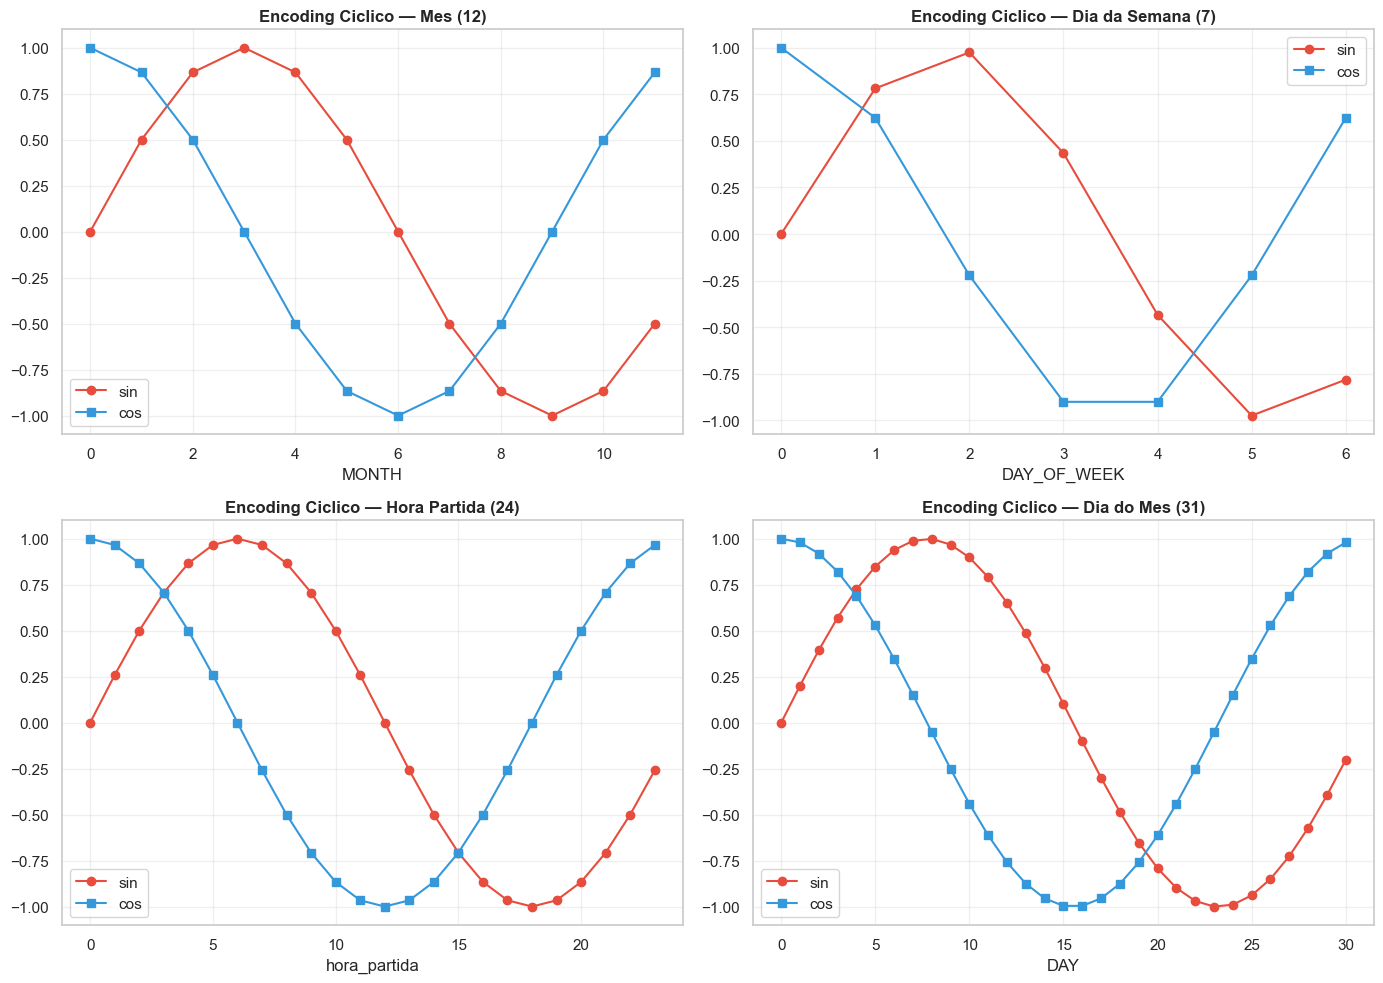

Colunas ciclicas criadas:
  MONTH_SIN: [-1.000, 1.000]
  MONTH_COS: [-1.000, 1.000]
  DAY_OF_WEEK_SIN: [-0.975, 0.975]
  DAY_OF_WEEK_COS: [-0.901, 1.000]
  hora_partida_SIN: [-1.000, 1.000]
  hora_partida_COS: [-1.000, 1.000]
  DAY_SIN: [-0.999, 0.999]
  DAY_COS: [-0.995, 1.000]


In [13]:
def cyclic_encode(df, col, max_val):
    """Cria colunas sin/cos para variavel ciclica."""
    df[f'{col}_SIN'] = np.sin(2 * np.pi * df[col] / max_val)
    df[f'{col}_COS'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

# MONTH: ciclo de 12
df = cyclic_encode(df, 'MONTH', 12)

# DAY_OF_WEEK: ciclo de 7
df = cyclic_encode(df, 'DAY_OF_WEEK', 7)

# hora_partida: ciclo de 24
df = cyclic_encode(df, 'hora_partida', 24)

# DAY: ciclo de 31
df = cyclic_encode(df, 'DAY', 31)

# Visualizar encoding ciclico
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, max_val, title in zip(
    axes.flatten(),
    ['MONTH', 'DAY_OF_WEEK', 'hora_partida', 'DAY'],
    [12, 7, 24, 31],
    ['Mes (12)', 'Dia da Semana (7)', 'Hora Partida (24)', 'Dia do Mes (31)']
):
    vals = np.arange(max_val)
    sin_vals = np.sin(2 * np.pi * vals / max_val)
    cos_vals = np.cos(2 * np.pi * vals / max_val)
    ax.plot(vals, sin_vals, 'o-', label='sin', color='#e74c3c')
    ax.plot(vals, cos_vals, 's-', label='cos', color='#3498db')
    ax.set_title(f'Encoding Ciclico — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Colunas ciclicas criadas:")
cyclic_cols = [c for c in df.columns if c.endswith('_SIN') or c.endswith('_COS')]
for c in cyclic_cols:
    print(f"  {c}: [{df[c].min():.3f}, {df[c].max():.3f}]")

## 11. Train/Test split (ANTES do target encoding)

O split deve ser feito **antes** do target encoding para evitar data leakage:
- Target encoding calcula a media do target por categoria.
- Se calcularmos no dataset inteiro, o teste "ve" informacao que vem do proprio teste.
- Estrategia: split estratificado por `ATRASO_SAIDA` para manter a proporcao de classes.

In [14]:
from sklearn.model_selection import train_test_split

# Separar features e targets
target_cols = ['ATRASO_SAIDA', 'ATRASO_CHEGADA']

X = df.drop(columns=target_cols)
y = df[target_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y['ATRASO_SAIDA']  # estratificar pelo target principal
)

print(f"Treino: {X_train.shape[0]:,} ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Teste:  {X_test.shape[0]:,} ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nProporção ATRASO_SAIDA no treino: {y_train['ATRASO_SAIDA'].mean()*100:.2f}%")
print(f"Proporção ATRASO_SAIDA no teste:  {y_test['ATRASO_SAIDA'].mean()*100:.2f}%")
print(f"\nProporção ATRASO_CHEGADA no treino: {y_train['ATRASO_CHEGADA'].mean()*100:.2f}%")
print(f"Proporção ATRASO_CHEGADA no teste:  {y_test['ATRASO_CHEGADA'].mean()*100:.2f}%")

Treino: 4,177,600 (80.0%)
Teste:  1,044,400 (20.0%)

Proporção ATRASO_SAIDA no treino: 23.13%
Proporção ATRASO_SAIDA no teste:  23.13%

Proporção ATRASO_CHEGADA no treino: 23.64%
Proporção ATRASO_CHEGADA no teste:  23.71%


## 12. Target encoding (fit no treino, transform em ambos)

Calculamos as medias **apenas no conjunto de treino** e aplicamos o mapeamento tanto no treino quanto no teste. Categorias que existem no teste mas nao no treino recebem a media global do treino.

In [15]:
def target_encode_fit(train_X, train_y, col, target, smoothing=10):
    """
    Calcula o mapeamento de target encoding no treino.
    Retorna: dict {categoria: valor_codificado}, global_mean
    """
    temp = train_X[[col]].copy()
    temp['__target__'] = train_y[target].values
    
    global_mean = temp['__target__'].mean()
    agg = temp.groupby(col)['__target__'].agg(['mean', 'count'])
    
    weight = agg['count'] / (agg['count'] + smoothing)
    agg['te'] = weight * agg['mean'] + (1 - weight) * global_mean
    
    return agg['te'].to_dict(), global_mean

def target_encode_transform(X, col, te_map, global_mean, new_col):
    """Aplica o mapeamento. Categorias desconhecidas recebem global_mean."""
    X[new_col] = X[col].map(te_map).fillna(global_mean)
    return X

# Categoricas de alta cardinalidade
cols_te = ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ORIGIN_STATE', 'DEST_STATE',
           'AIRLINE', 'ROTA']

# Guardar mapeamentos para reproducibilidade
te_maps = {}

for target in ['ATRASO_SAIDA', 'ATRASO_CHEGADA']:
    target_suffix = 'SAI' if 'SAIDA' in target else 'CHE'
    
    for col in cols_te:
        new_col = f'{col}_TE_{target_suffix}'
        
        # Fit no treino
        te_map, global_mean = target_encode_fit(X_train, y_train, col, target)
        te_maps[(col, target)] = (te_map, global_mean)
        
        # Transform em ambos
        X_train = target_encode_transform(X_train, col, te_map, global_mean, new_col)
        X_test  = target_encode_transform(X_test,  col, te_map, global_mean, new_col)
        
        # Verificar se teste tem categorias desconhecidas
        unknown = set(X_test[col].unique()) - set(te_map.keys())
        unknown_info = f" ({len(unknown)} categorias desconhecidas no teste)" if unknown else ""
        
        print(f"  {new_col}: treino=[{X_train[new_col].min():.4f}, {X_train[new_col].max():.4f}] "
              f"| teste=[{X_test[new_col].min():.4f}, {X_test[new_col].max():.4f}]{unknown_info}")

print(f"\nColunas de TE criadas: {len(cols_te) * 2}")

  ORIGIN_AIRPORT_TE_SAI: treino=[0.1604, 0.3111] | teste=[0.1604, 0.3111]
  DESTINATION_AIRPORT_TE_SAI: treino=[0.1665, 0.2905] | teste=[0.1665, 0.2905]
  ORIGIN_STATE_TE_SAI: treino=[0.1299, 0.3060] | teste=[0.1299, 0.3060]
  DEST_STATE_TE_SAI: treino=[0.1422, 0.2807] | teste=[0.1422, 0.2807]
  AIRLINE_TE_SAI: treino=[0.1084, 0.3302] | teste=[0.1084, 0.3302]
  ROTA_TE_SAI: treino=[0.1655, 0.2775] | teste=[0.1655, 0.2775]
  ORIGIN_AIRPORT_TE_CHE: treino=[0.1775, 0.2850] | teste=[0.1775, 0.2850]
  DESTINATION_AIRPORT_TE_CHE: treino=[0.1669, 0.3088] | teste=[0.1669, 0.3088]
  ORIGIN_STATE_TE_CHE: treino=[0.1577, 0.2795] | teste=[0.1577, 0.2795]
  DEST_STATE_TE_CHE: treino=[0.1674, 0.2787] | teste=[0.1674, 0.2787]
  AIRLINE_TE_CHE: treino=[0.1712, 0.3604] | teste=[0.1712, 0.3604]
  ROTA_TE_CHE: treino=[0.1785, 0.2728] | teste=[0.1785, 0.2728]

Colunas de TE criadas: 12


## 13. One-hot encoding e limpeza de colunas originais

In [16]:
# One-hot para categoricas de baixa cardinalidade
cols_ohe = ['PERIODO_DIA', 'TIPO_DIA_SEMANA', 'ESTACAO', 'FAIXA_DISTANCIA',
            'DIA_MES_GRUPO', 'dia_semana']
cols_ohe = [c for c in cols_ohe if c in X_train.columns]

print("One-hot encoding para:")
for c in cols_ohe:
    print(f"  {c}: {X_train[c].nunique()} categorias")

# Fit no treino para garantir mesmas colunas no teste
X_train = pd.get_dummies(X_train, columns=cols_ohe, drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=cols_ohe, drop_first=True, dtype=int)

# Alinhar colunas: teste pode ter categorias diferentes
# Adicionar colunas que existem no treino mas nao no teste (com 0)
missing_in_test = set(X_train.columns) - set(X_test.columns)
for col in missing_in_test:
    X_test[col] = 0
    
# Remover colunas que existem no teste mas nao no treino
extra_in_test = set(X_test.columns) - set(X_train.columns)
X_test.drop(columns=list(extra_in_test), inplace=True, errors='ignore')

# Garantir mesma ordem de colunas
X_test = X_test[X_train.columns]

if missing_in_test:
    print(f"\n{len(missing_in_test)} colunas adicionadas ao teste (com 0)")
if extra_in_test:
    print(f"{len(extra_in_test)} colunas extras removidas do teste")

print(f"\nShape treino: {X_train.shape}")
print(f"Shape teste:  {X_test.shape}")

One-hot encoding para:
  PERIODO_DIA: 4 categorias
  TIPO_DIA_SEMANA: 3 categorias
  ESTACAO: 4 categorias
  FAIXA_DISTANCIA: 3 categorias
  DIA_MES_GRUPO: 3 categorias
  dia_semana: 7 categorias

Shape treino: (4177600, 60)
Shape teste:  (1044400, 60)


In [17]:
# Dropar colunas string originais que ja foram codificadas
cols_drop_encoded = ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ORIGIN_STATE',
                     'DEST_STATE', 'AIRLINE', 'ROTA']

# Dropar colunas temporais originais que ja tem encoding ciclico
cols_drop_cyclic = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'hora_partida']

all_drops = cols_drop_encoded + cols_drop_cyclic
all_drops = [c for c in all_drops if c in X_train.columns]

X_train.drop(columns=all_drops, inplace=True)
X_test.drop(columns=all_drops, inplace=True)

print(f"Colunas removidas: {len(all_drops)}")
print(f"Shape treino: {X_train.shape}")
print(f"Shape teste:  {X_test.shape}")

# Verificacao
print(f"\nNulos treino: {X_train.isnull().sum().sum()}")
print(f"Nulos teste:  {X_test.isnull().sum().sum()}")
print(f"Colunas object treino: {X_train.select_dtypes(include='object').columns.tolist()}")
print(f"Colunas object teste:  {X_test.select_dtypes(include='object').columns.tolist()}")

Colunas removidas: 10
Shape treino: (4177600, 50)
Shape teste:  (1044400, 50)

Nulos treino: 0
Nulos teste:  0
Colunas object treino: []
Colunas object teste:  []


## 14. Feature Selection -- Remover features com alta correlacao entre si

Features altamente correlacionadas (>0.90) carregam informacao redundante e podem:
- Atrapalhar a interpretabilidade
- Inflacionar a importancia de features
- Aumentar dimensionalidade sem ganho preditivo

Estrategia: calcular a matriz de correlacao no **treino**, identificar pares com |r| > 0.90, e remover uma de cada par.

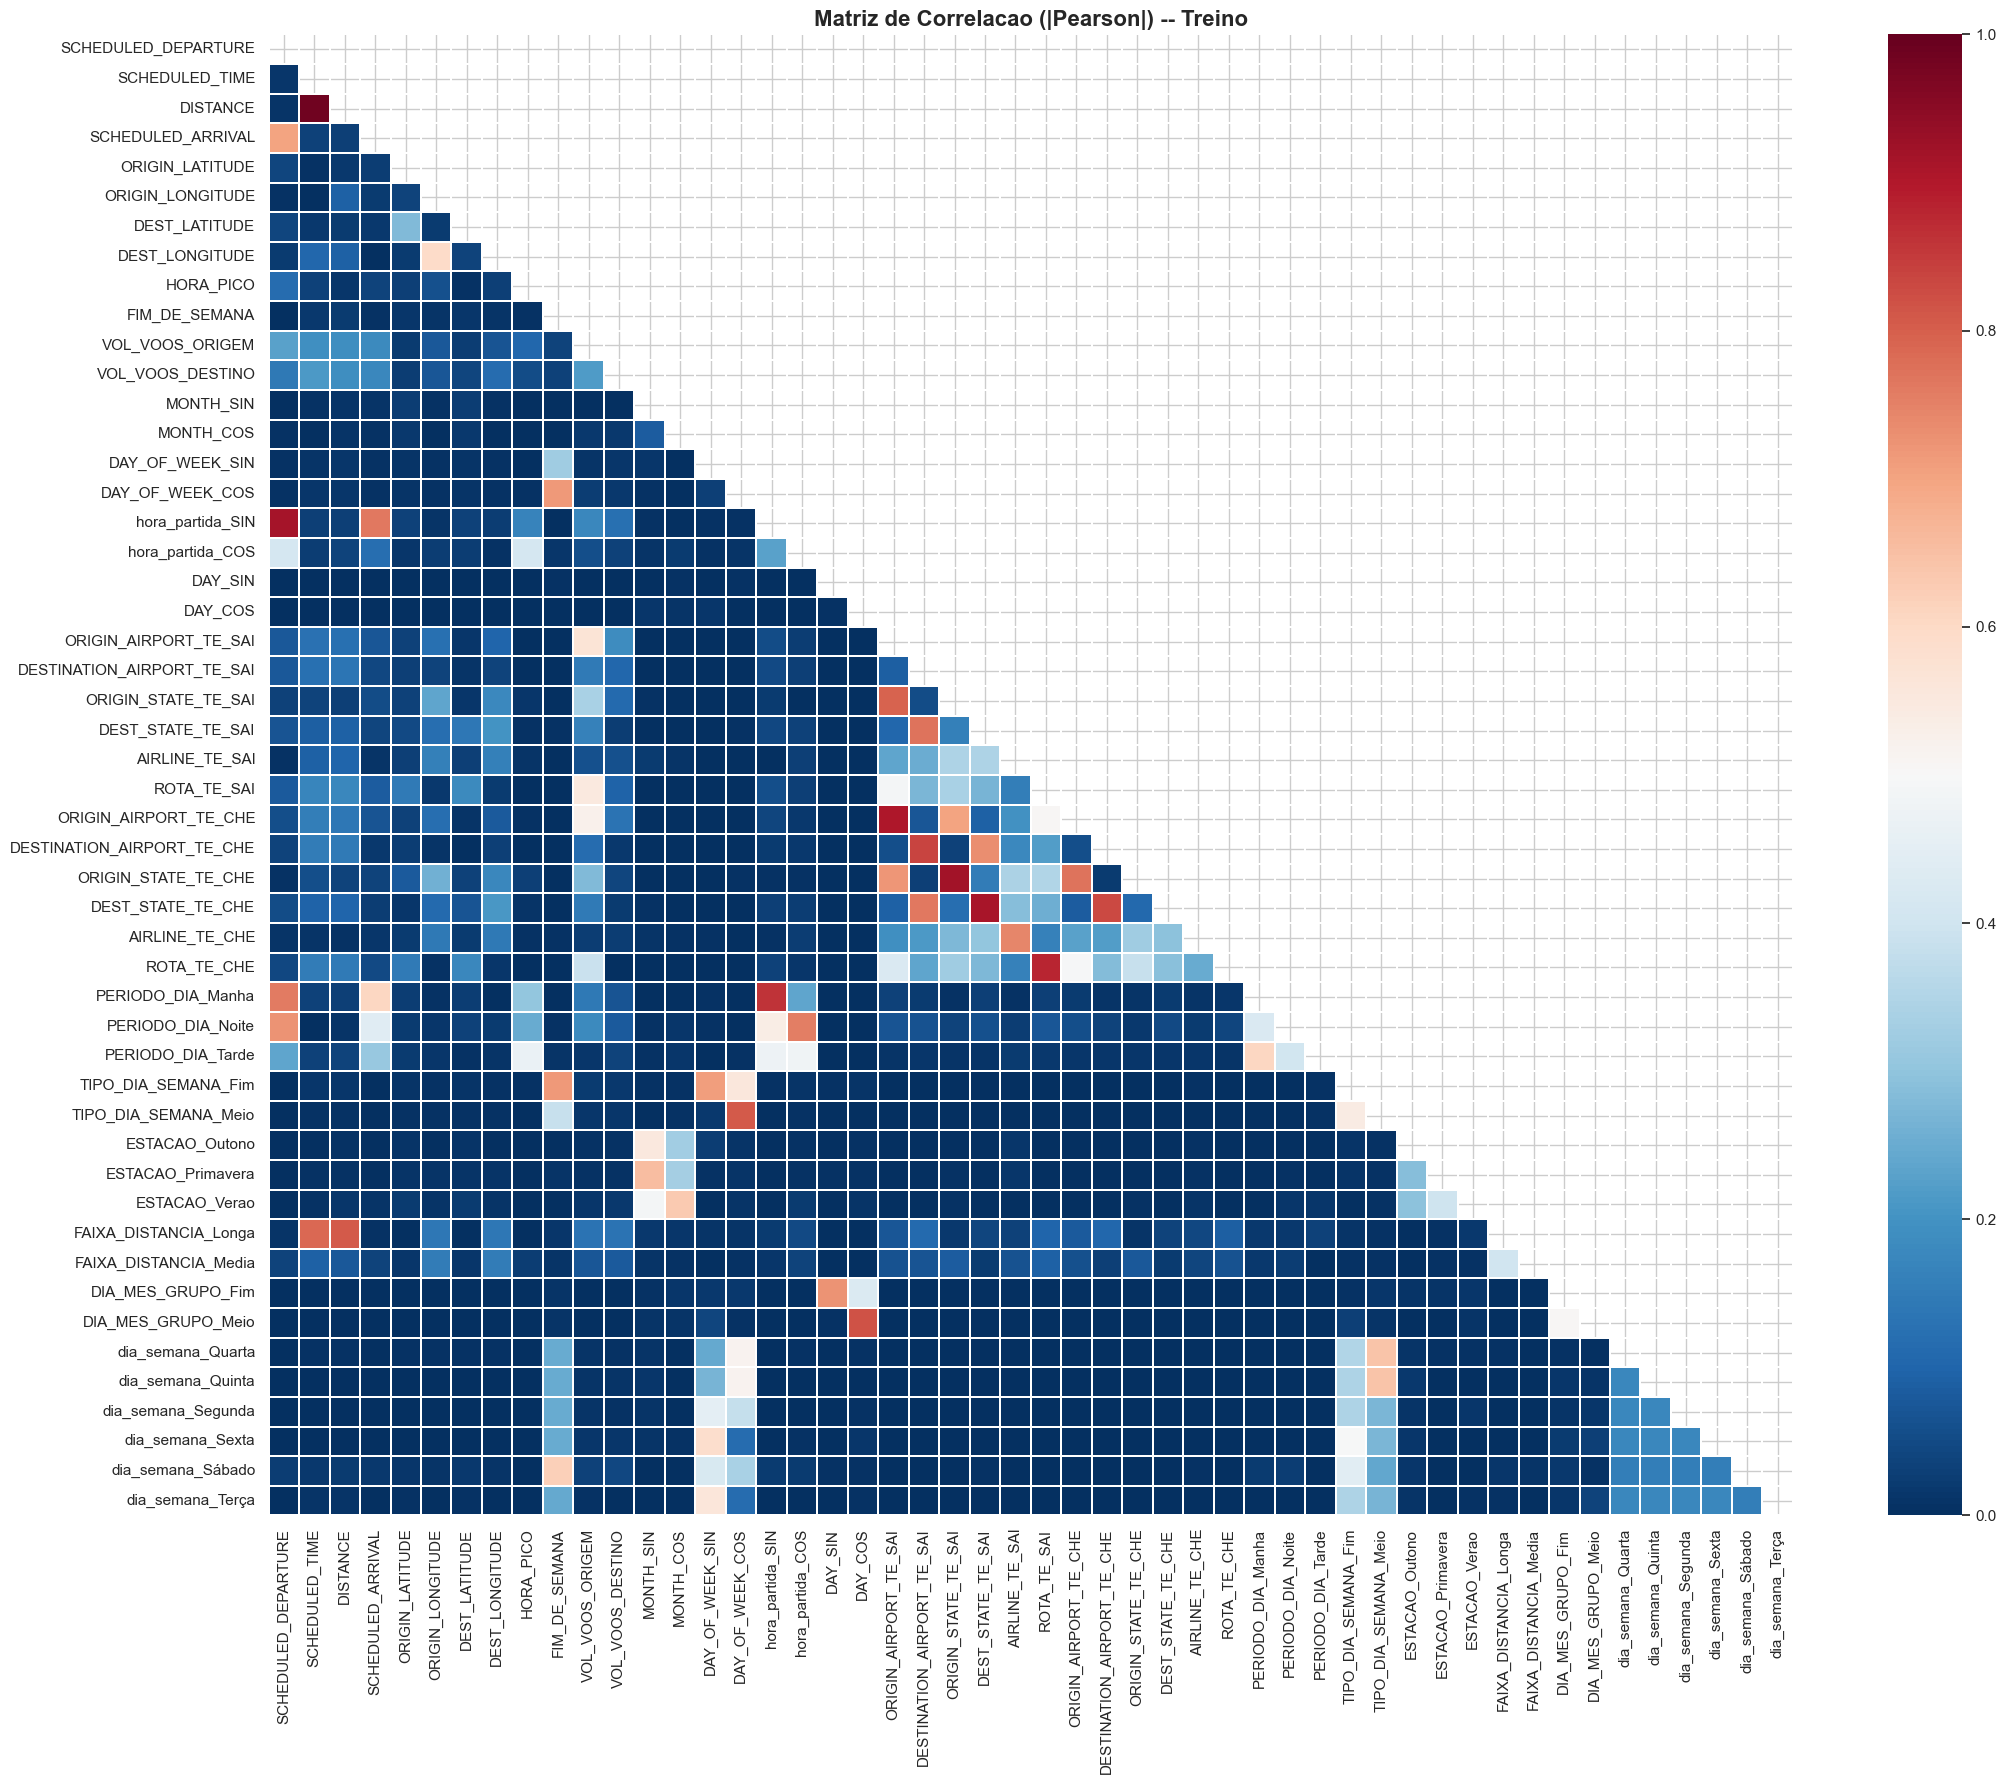

In [18]:
# Matriz de correlacao no treino
corr = X_train.corr(method='pearson').abs()

# Heatmap geral
fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0.5, vmin=0, vmax=1,
            linewidths=0.3, ax=ax, annot=False)
ax.set_title('Matriz de Correlacao (|Pearson|) -- Treino', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
CORR_THRESHOLD = 0.70

# Identificar pares com alta correlacao
upper = corr.where(mask == False)  # triangular inferior
high_corr_pairs = []

for col in upper.columns:
    for idx in upper.index:
        val = upper.loc[idx, col]
        if pd.notna(val) and val > CORR_THRESHOLD and idx != col:
            high_corr_pairs.append((idx, col, round(val, 4)))

if high_corr_pairs:
    df_pairs = pd.DataFrame(high_corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlacao'])
    df_pairs = df_pairs.sort_values('Correlacao', ascending=False)
    print(f"Pares com correlacao > {CORR_THRESHOLD}:")
    print(df_pairs.to_string(index=False))
else:
    print(f"Nenhum par com correlacao > {CORR_THRESHOLD}")

Pares com correlacao > 0.7:
                 Feature_1                  Feature_2  Correlacao
                  DISTANCE             SCHEDULED_TIME      0.9847
       ORIGIN_STATE_TE_CHE        ORIGIN_STATE_TE_SAI      0.9188
          hora_partida_SIN        SCHEDULED_DEPARTURE      0.9175
         DEST_STATE_TE_CHE          DEST_STATE_TE_SAI      0.9134
     ORIGIN_AIRPORT_TE_CHE      ORIGIN_AIRPORT_TE_SAI      0.9033
               ROTA_TE_CHE                ROTA_TE_SAI      0.8790
         PERIODO_DIA_Manha           hora_partida_SIN      0.8629
DESTINATION_AIRPORT_TE_CHE DESTINATION_AIRPORT_TE_SAI      0.8360
         DEST_STATE_TE_CHE DESTINATION_AIRPORT_TE_CHE      0.8312
        DIA_MES_GRUPO_Meio                    DAY_COS      0.8199
     FAIXA_DISTANCIA_Longa                   DISTANCE      0.8074
      TIPO_DIA_SEMANA_Meio            DAY_OF_WEEK_COS      0.8054
       ORIGIN_STATE_TE_SAI      ORIGIN_AIRPORT_TE_SAI      0.7947
     FAIXA_DISTANCIA_Longa             SCHEDULED

In [20]:
# Remover features redundantes: para cada par correlacionado,
# manter a que tem maior correlacao com o target (ATRASO_SAIDA)
cols_to_remove = set()

if high_corr_pairs:
    # Correlacao de cada feature com o target (no treino)
    corr_with_target = X_train.corrwith(y_train['ATRASO_SAIDA']).abs()

    for f1, f2, corr_val in high_corr_pairs:
        if f1 in cols_to_remove or f2 in cols_to_remove:
            continue  # ja marcada para remocao
        
        # Manter a feature mais correlacionada com o target
        c1 = corr_with_target.get(f1, 0)
        c2 = corr_with_target.get(f2, 0)
        
        remove = f2 if c1 >= c2 else f1
        keep = f1 if c1 >= c2 else f2
        cols_to_remove.add(remove)
        print(f"  Remover '{remove}' (corr_target={min(c1,c2):.4f}) | "
              f"Manter '{keep}' (corr_target={max(c1,c2):.4f}) | "
              f"Correlacao entre si: {corr_val:.4f}")

if cols_to_remove:
    X_train.drop(columns=list(cols_to_remove), inplace=True)
    X_test.drop(columns=list(cols_to_remove), inplace=True)
    print(f"\n{len(cols_to_remove)} features removidas por alta correlacao.")
else:
    print("Nenhuma feature removida.")

print(f"\nShape final treino: {X_train.shape}")
print(f"Shape final teste:  {X_test.shape}")

  Remover 'SCHEDULED_ARRIVAL' (corr_target=0.1544) | Manter 'SCHEDULED_DEPARTURE' (corr_target=0.1827) | Correlacao entre si: 0.7028
  Remover 'SCHEDULED_DEPARTURE' (corr_target=0.1827) | Manter 'hora_partida_SIN' (corr_target=0.1870) | Correlacao entre si: 0.9175
  Remover 'DISTANCE' (corr_target=0.0293) | Manter 'SCHEDULED_TIME' (corr_target=0.0300) | Correlacao entre si: 0.9847
  Remover 'FAIXA_DISTANCIA_Longa' (corr_target=0.0148) | Manter 'SCHEDULED_TIME' (corr_target=0.0300) | Correlacao entre si: 0.7884
  Remover 'DAY_OF_WEEK_COS' (corr_target=0.0053) | Manter 'FIM_DE_SEMANA' (corr_target=0.0162) | Correlacao entre si: 0.7157
  Remover 'TIPO_DIA_SEMANA_Fim' (corr_target=0.0114) | Manter 'FIM_DE_SEMANA' (corr_target=0.0162) | Correlacao entre si: 0.7156
  Remover 'PERIODO_DIA_Manha' (corr_target=0.1528) | Manter 'hora_partida_SIN' (corr_target=0.1870) | Correlacao entre si: 0.8629
  Remover 'hora_partida_COS' (corr_target=0.0443) | Manter 'PERIODO_DIA_Noite' (corr_target=0.1180) 

In [21]:
# Correlacao final com os targets
print("="*60)
print("Correlacao das features restantes com os targets (treino)")
print("="*60)

for target in ['ATRASO_SAIDA', 'ATRASO_CHEGADA']:
    corr_target = X_train.corrwith(y_train[target]).abs().sort_values(ascending=False)
    print(f"\n--- {target} ---")
    print(corr_target.to_string())
    print()

Correlacao das features restantes com os targets (treino)

--- ATRASO_SAIDA ---
hora_partida_SIN         0.186990
PERIODO_DIA_Noite        0.117971
AIRLINE_TE_SAI           0.110362
ORIGIN_AIRPORT_TE_SAI    0.085723
VOL_VOOS_ORIGEM          0.072045
PERIODO_DIA_Tarde        0.069148
DEST_STATE_TE_SAI        0.065115
ESTACAO_Outono           0.063789
ROTA_TE_SAI              0.055259
ESTACAO_Verao            0.037532
HORA_PICO                0.032745
SCHEDULED_TIME           0.029959
MONTH_SIN                0.028698
ORIGIN_LONGITUDE         0.023588
dia_semana_Sábado        0.021138
FAIXA_DISTANCIA_Media    0.017632
DEST_LONGITUDE           0.016287
FIM_DE_SEMANA            0.016230
MONTH_COS                0.014092
VOL_VOOS_DESTINO         0.013585
ESTACAO_Primavera        0.013248
dia_semana_Segunda       0.012791
dia_semana_Quinta        0.012478
DIA_MES_GRUPO_Fim        0.009071
ORIGIN_LATITUDE          0.008425
DIA_MES_GRUPO_Meio       0.006454
dia_semana_Quarta        0.006384
DA

## 15. Normalizacao numerica (StandardScaler)

Aplicamos **StandardScaler** (z-score: media=0, desvio=1) nas features numericas continuas.

- **Fit** somente no treino para evitar data leakage
- **Transform** em treino e teste
- Colunas binarias (0/1) sao excluidas da normalizacao pois ja estao na escala correta

In [22]:
# Identificar colunas para escalar
# Excluir binarias (OHE, FIM_DE_SEMANA, HORA_PICO, targets de encoding ciclico 0/1, etc.)
binary_cols = [c for c in X_train.columns if X_train[c].nunique() <= 2]

# Features numericas continuas = todas menos as binarias
cols_to_scale = [c for c in X_train.columns if c not in binary_cols]

print(f"Total features: {X_train.shape[1]}")
print(f"Binarias (nao escalar): {len(binary_cols)}")
print(f"Continuas (escalar):    {len(cols_to_scale)}")
print(f"\nBinarias: {binary_cols}")
print(f"\nContinuas: {cols_to_scale}")

# Fit no treino, transform em ambos
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(f"\n{'='*60}")
print("Normalizacao aplicada com sucesso!")
print(f"{'='*60}")
print(f"\nEstatisticas pos-scaling (treino):")
print(X_train[cols_to_scale].describe().round(4).to_string())

Total features: 32
Binarias (nao escalar): 17
Continuas (escalar):    15

Binarias: ['HORA_PICO', 'FIM_DE_SEMANA', 'PERIODO_DIA_Noite', 'PERIODO_DIA_Tarde', 'TIPO_DIA_SEMANA_Meio', 'ESTACAO_Outono', 'ESTACAO_Primavera', 'ESTACAO_Verao', 'FAIXA_DISTANCIA_Media', 'DIA_MES_GRUPO_Fim', 'DIA_MES_GRUPO_Meio', 'dia_semana_Quarta', 'dia_semana_Quinta', 'dia_semana_Segunda', 'dia_semana_Sexta', 'dia_semana_Sábado', 'dia_semana_Terça']

Continuas: ['SCHEDULED_TIME', 'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE', 'DEST_LATITUDE', 'DEST_LONGITUDE', 'VOL_VOOS_ORIGEM', 'VOL_VOOS_DESTINO', 'MONTH_SIN', 'MONTH_COS', 'DAY_OF_WEEK_SIN', 'hora_partida_SIN', 'ORIGIN_AIRPORT_TE_SAI', 'DEST_STATE_TE_SAI', 'AIRLINE_TE_SAI', 'ROTA_TE_SAI']

Normalizacao aplicada com sucesso!

Estatisticas pos-scaling (treino):
       SCHEDULED_TIME  ORIGIN_LATITUDE  ORIGIN_LONGITUDE  DEST_LATITUDE  DEST_LONGITUDE  VOL_VOOS_ORIGEM  VOL_VOOS_DESTINO     MONTH_SIN     MONTH_COS  DAY_OF_WEEK_SIN  hora_partida_SIN  ORIGIN_AIRPORT_TE_SAI  

## 16. Revisao final e salvamento

In [23]:
# Revisao final
print(f"{'='*60}")
print(f"REVISAO FINAL")
print(f"{'='*60}")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"\nNulos treino: {X_train.isnull().sum().sum()}")
print(f"Nulos teste:  {X_test.isnull().sum().sum()}")
print(f"\nDtypes treino:\n{X_train.dtypes.value_counts()}")
print(f"\nFeatures ({X_train.shape[1]}):")
for c in sorted(X_train.columns):
    print(f"  {c}")

X_train.head(3)

REVISAO FINAL
X_train: (4177600, 32)
X_test:  (1044400, 32)
y_train: (4177600, 2)
y_test:  (1044400, 2)

Nulos treino: 0
Nulos teste:  0

Dtypes treino:
int64      17
float64    15
Name: count, dtype: int64

Features (32):
  AIRLINE_TE_SAI
  DAY_OF_WEEK_SIN
  DEST_LATITUDE
  DEST_LONGITUDE
  DEST_STATE_TE_SAI
  DIA_MES_GRUPO_Fim
  DIA_MES_GRUPO_Meio
  ESTACAO_Outono
  ESTACAO_Primavera
  ESTACAO_Verao
  FAIXA_DISTANCIA_Media
  FIM_DE_SEMANA
  HORA_PICO
  MONTH_COS
  MONTH_SIN
  ORIGIN_AIRPORT_TE_SAI
  ORIGIN_LATITUDE
  ORIGIN_LONGITUDE
  PERIODO_DIA_Noite
  PERIODO_DIA_Tarde
  ROTA_TE_SAI
  SCHEDULED_TIME
  TIPO_DIA_SEMANA_Meio
  VOL_VOOS_DESTINO
  VOL_VOOS_ORIGEM
  dia_semana_Quarta
  dia_semana_Quinta
  dia_semana_Segunda
  dia_semana_Sexta
  dia_semana_Sábado
  dia_semana_Terça
  hora_partida_SIN


,SCHEDULED_TIME,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DEST_LATITUDE,DEST_LONGITUDE,HORA_PICO,FIM_DE_SEMANA,VOL_VOOS_ORIGEM,VOL_VOOS_DESTINO,MONTH_SIN,...,ESTACAO_Verao,FAIXA_DISTANCIA_Media,DIA_MES_GRUPO_Fim,DIA_MES_GRUPO_Meio,dia_semana_Quarta,dia_semana_Quinta,dia_semana_Segunda,dia_semana_Sexta,dia_semana_Sábado,dia_semana_Terça
4762616,2.474897,0.165007,-1.473267,0.667772,1.198095,0,0,-0.672150,-0.827326,-0.096639,...,0,0,0,0,0,0,0,0,0,1
2119147,-0.430178,-0.496961,0.612731,0.858415,0.430118,0,0,-0.798532,-0.827326,0.633116,...,0,1,0,1,0,0,0,0,0,1
412098,-0.308570,0.692342,-0.901740,-0.647201,-1.187742,0,0,-0.732332,-0.778511,0.633116,...,0,1,1,0,1,0,0,0,0,0


In [24]:
# Salvar treino e teste separados
X_train.to_csv('dados/X_train.csv', index=False)
X_test.to_csv('dados/X_test.csv', index=False)
y_train.to_csv('dados/y_train.csv', index=False)
y_test.to_csv('dados/y_test.csv', index=False)

print("Arquivos salvos:")
print(f"  dados/X_train.csv  ({X_train.shape[0]:,} x {X_train.shape[1]})")
print(f"  dados/X_test.csv   ({X_test.shape[0]:,} x {X_test.shape[1]})")
print(f"  dados/y_train.csv  ({y_train.shape[0]:,} x {y_train.shape[1]})")
print(f"  dados/y_test.csv   ({y_test.shape[0]:,} x {y_test.shape[1]})")
print(f"\nMemoria total: {(X_train.memory_usage(deep=True).sum() + X_test.memory_usage(deep=True).sum()) / 1e6:.1f} MB")

Arquivos salvos:
  dados/X_train.csv  (4,177,600 x 32)
  dados/X_test.csv   (1,044,400 x 32)
  dados/y_train.csv  (4,177,600 x 2)
  dados/y_test.csv   (1,044,400 x 2)

Memoria total: 1378.6 MB
